In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import mne
from mne import create_info, find_events, Epochs, EpochsArray, set_eeg_reference
from mne.baseline import rescale
from mne.stats import bootstrap_confidence_interval

## Парсинг данных

In [2]:
time_intervals = pd.read_csv("emo_time_intervals.csv")
time_intervals["duration"] = time_intervals["end"] - time_intervals["start"]
image_intervals = time_intervals[time_intervals['event']=='image']
image_intervals

,event,start,end,duration
1,image,2075,2081,6
3,image,2084,2090,6
5,image,2093,2099,6
7,image,2102,2108,6
9,image,2111,2117,6
11,image,2120,2126,6
13,image,2129,2135,6
15,image,2138,2144,6
17,image,2147,2153,6
19,image,2156,2162,6


In [3]:
subject_names = np.arange(1, 8)
emotions_df = pd.read_csv('emotions.csv')

In [4]:
emotions_df

,subject,image_1_valence,image_1_arousal,image_2_valence,image_2_arousal,image_3_valence,image_3_arousal,image_4_valence,image_4_arousal,image_5_valence,...,image_11_valence,image_11_arousal,image_12_valence,image_12_arousal,image_13_valence,image_13_arousal,image_14_valence,image_14_arousal,image_15_valence,image_15_arousal
0,1,8,6,4,3,6,3,9,8.0,8,...,6,5,5,3.5,10,6.5,3,5.5,7,5.5
1,2,5,2,7,4,5,4,8,6.0,3,...,4,6,7,4.0,10,8.0,9,8.0,10,8.0
2,3,5,0,3,4,5,5,8,7.0,10,...,3,0,4,1.0,10,10.0,9,9.0,10,10.0
3,4,5,5,7,5,5,0,9,6.0,5,...,5,0,3,5.0,7,7.0,7,3.0,5,5.0
4,5,7,7,6,7,8,7,6,7.0,10,...,8,8,8,8.0,7,6.0,7,7.0,9,7.0
5,6,5,0,4,2,2,7,8,7.5,9,...,3,3,5,5.0,10,10.0,10,10.0,10,10.0
6,7,5,2,5,2,5,2,9,7.0,9,...,5,0,5,0.0,8,6.0,8,6.0,9,7.0


In [5]:
def process_participant(eeg_path: str, time_intervals: pd.DataFrame) -> list:
    raw = mne.io.read_raw_edf(eeg_path, preload=True)
    raw.drop_channels(['LABEL'])
    raw = raw.resample(200)
    annotations = mne.Annotations(
        onset=time_intervals['start'],
        duration=time_intervals['duration'],
        description=time_intervals['event']
      )
    raw.set_annotations(annotations)

    montage = mne.channels.make_standard_montage('standard_1020')
    raw.set_montage(montage)
    raw.crop(tmin=60, tmax=2230)
    filtered_eeg = process_eeg(raw, 1, 45)
    return filtered_eeg

def process_eeg(mne_eeg, low_frequency, high_frequency):
    procesed_eeg = mne_eeg.copy()
    procesed_eeg.filter(low_frequency, high_frequency, method='fir', fir_design='firwin')
    mne.set_eeg_reference(procesed_eeg)
    return procesed_eeg

def split_to_epochs(mne_eeg):
    epochs = mne.Epochs(
        mne_eeg,
        events=None,
        event_id=None,
        tmin=-0.2,
        tmax=6,
        baseline=(-0.2, 0),
        preload=True
    )
    return epochs

In [6]:
subject_epochs = []
for subject_name in subject_names:
    subject_path = f'{subject_name}.edf'
    filtered_eeg = process_participant(subject_path, image_intervals)
    epochs = split_to_epochs(filtered_eeg)
    subject_epochs.append(epochs)

Extracting EDF parameters from d:\Study\StudyStudy\Sem2\functional state analysis\Lab5\1.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 561249  =      0.000 ...  2244.996 secs...


C:\Users\Ivan_\AppData\Local\Temp\ipykernel_22364\616866511.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(eeg_path, preload=True)
C:\Users\Ivan_\AppData\Local\Temp\ipykernel_22364\616866511.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(eeg_path, preload=True)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 661 samples (3.305 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: [np.str_('image')]
Ignoring annotation durations and creating fixed-duration epochs around annotation onsets.
Not setting metadata
15 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 15 events and 1241 original time poi

C:\Users\Ivan_\AppData\Local\Temp\ipykernel_22364\616866511.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(eeg_path, preload=True)
C:\Users\Ivan_\AppData\Local\Temp\ipykernel_22364\616866511.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(eeg_path, preload=True)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 661 samples (3.305 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: [np.str_('image')]
Ignoring annotation durations and creating fixed-duration epochs around annotation onsets.
Not setting metadata
15 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 15 events and 1241 original time poi

...

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 661 samples (3.305 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: [np.str_('image')]
Ignoring annotation durations and creating fixed-duration epochs around annotation onsets.
Not setting metadata
15 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 15 events and 1241 original time poi

C:\Users\Ivan_\AppData\Local\Temp\ipykernel_22364\616866511.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(eeg_path, preload=True)
C:\Users\Ivan_\AppData\Local\Temp\ipykernel_22364\616866511.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(eeg_path, preload=True)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 661 samples (3.305 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: [np.str_('image')]
Ignoring annotation durations and creating fixed-duration epochs around annotation onsets.
Not setting metadata
15 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 15 events and 1241 original time poi

C:\Users\Ivan_\AppData\Local\Temp\ipykernel_22364\616866511.py:2: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(eeg_path, preload=True)
C:\Users\Ivan_\AppData\Local\Temp\ipykernel_22364\616866511.py:2: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(eeg_path, preload=True)


Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 45 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 45.00 Hz
- Upper transition bandwidth: 11.25 Hz (-6 dB cutoff frequency: 50.62 Hz)
- Filter length: 661 samples (3.305 s)

EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.
Used Annotations descriptions: [np.str_('image')]
Ignoring annotation durations and creating fixed-duration epochs around annotation onsets.
Not setting metadata
15 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 15 events and 1241 original time poi

In [7]:
bands = {
    "delta": (1.5, 4),
    "theta": (4, 7.5),
    "alpha": (7.5, 14),
    "beta": (14, 30),
    "gamma": (30, 45)
}

In [8]:
from scipy import signal
from scipy.signal import butter, sosfilt, sosfreqz
def butter_filter(epochs_data, low_f, high_f, fs):
    sos = butter(5, [low_f, high_f], 'band', fs=fs, output='sos')
    return signal.sosfilt(sos, epochs_data, axis=-1)

def calculate_DE(data):
    var = np.var(data, axis=-1, ddof=1)
    return np.log(2 * np.pi * np.e * var)/2

def compute_DE(epochs_data, bands, fs):
    features = []
    for band in bands.values():
        filtered = butter_filter(epochs_data, band[0], band[1], fs)
        features.append(calculate_DE(filtered))
    return features

In [9]:
def compute_psd(epochs, fmin, fmax):
    n_times = epochs.get_data().shape[2]
    n_fft = min(512, n_times)
    psd = epochs.compute_psd(
        method='welch',
        fmin=fmin,
        fmax=fmax,
        n_fft=n_fft,
        n_overlap=n_fft // 2,
        average='mean'
    )
    return psd

In [10]:
def compute_psd_for_epochs_df(epochs, fmin, fmax):
    epoch_psds = []
    psd = compute_psd(epochs, fmin, fmax)
    freqs = psd.freqs
    for i, epoch_psd in enumerate(psd.get_data()):
        total_band_mask = (freqs >= fmin) & (freqs < fmax)
        total_psd_event = epoch_psd[:, total_band_mask].sum(axis=1)
        for band in bands:
            frequence_range = bands[band]
            band_mask = (freqs >= frequence_range[0]) & (freqs < frequence_range[1])
            dot_psd = epoch_psd[:, band_mask].sum(axis=1) / total_psd_event
            for channel_idx, channel in enumerate(epochs.ch_names):
                epoch_psds.append([i + 1, band, channel, dot_psd[channel_idx]])

    psd_df = pd.DataFrame(epoch_psds, columns=["image", "band", "channel", "psd"])
    return psd_df

In [11]:
psd_dfs = []
for subject_idx, subject_epoch in enumerate(subject_epochs):
  psd_df = compute_psd_for_epochs_df(subject_epochs[0], 1, 45)
  psd_df['subject'] = subject_idx + 1
  psd_dfs.append(psd_df)
spectrum_df = pd.concat(psd_dfs)

Effective window size : 2.560 (s)


Effective window size : 2.560 (s)
Effective window size : 2.560 (s)
Effective window size : 2.560 (s)
Effective window size : 2.560 (s)
Effective window size : 2.560 (s)
Effective window size : 2.560 (s)


In [12]:
spectrum_df

,image,band,channel,psd,subject
0,1,delta,Fp1,0.724874,1
1,1,delta,Fp2,0.744452,1
2,1,delta,F7,0.491809,1
3,1,delta,F3,0.442987,1
4,1,delta,Fz,0.587868,1
...,...,...,...,...,...
2245,15,gamma,P4,0.042619,7
2246,15,gamma,T6,0.084015,7
2247,15,gamma,O1,0.044819,7
2248,15,gamma,Oz,0.044355,7


## Обучение SVM модели

In [13]:
import random

def train_val_test_split(elements):
  items = elements.copy()
  random.shuffle(items)
  return items[:4], items[4], items[5:]


In [14]:
train_subj, val_subj, test_subj = train_val_test_split(subject_names)

In [15]:
train_subj

array([4, 1, 6, 2])

In [16]:
val_subj

np.int64(5)

In [17]:
test_subj

array([3, 7])

In [18]:
def get_x_data(df, subject_ids):
  x = []
  for subject_i in subject_ids:
    subj_df = df[df['subject'] == subject_i]
    for image_i in range(1, 16):
      x.append(subj_df[subj_df['image'] == image_i]['psd'].to_list())
  return x

In [19]:
train_x = get_x_data(spectrum_df, train_subj)
val_x = get_x_data(spectrum_df, [val_subj])
test_x = get_x_data(spectrum_df, test_subj)

In [20]:
def get_y_data(emotion_df, subject_ids):
  y_valence = []
  y_arousal = []

  for subject_i in subject_ids:
      subj_df = emotion_df[emotion_df['subject'] == subject_i]
      for image_i in range(1, 16):
        y_valence.append(subj_df[f'image_{image_i}_valence'].iloc[0])
        y_arousal.append(subj_df[f'image_{image_i}_arousal'].iloc[0])
  
  y_valence = (y_valence - np.mean(y_valence))/np.std(y_valence)
  y_arousal = (y_arousal - np.mean(y_arousal))/np.std(y_arousal)
  return y_valence, y_arousal

def shuffle_data(x_data, y_data):
    indices = np.random.permutation(len(x_data))
    x_data = x_data[indices]
    y_data = y_data[indices]
    return x_data, y_data

In [21]:
train_y_valence, train_y_arousal = get_y_data(emotions_df, train_subj)
val_y_valence, val_y_arousal = get_y_data(emotions_df, [val_subj])
test_y_valence, test_y_arousal = get_y_data(emotions_df, test_subj)

In [ ]:
shuffled_train_x, shuffled_train_y_valence  = shuffle_data(np.array(train_x), np.array(train_y_valence))

In [22]:
import numpy as np
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import KFold, cross_val_score

In [23]:
from sklearn.model_selection import GridSearchCV
def hyperparameters_selection(train_x, train_y):
    tuned_parameters = [{   'kernel': ['linear', 'poly', 'rbf', 'sigmoid'], 
                            'gamma': [1e-2, 1e-3, 1e-4],
                            'C': [0.1, 1, 10, 100], 
                            'epsilon': [0.01, 0.1, 0.5, 0.6, 0.8]}]
    grid = GridSearchCV(SVR(), 
                        tuned_parameters, 
                        cv=5,
                        scoring='neg_root_mean_squared_error',
        n_jobs=-1)

    grid.fit(train_x, train_y)
    return grid.best_params_, -grid.best_score_

In [24]:
print(f"{'='*10}Valence{'='*10}")
val_best_params, val_best_score = hyperparameters_selection(train_x, train_y_valence)
print('Best params:', val_best_params)
print('Best score:', val_best_score)
print(f"{'='*10}Arousal{'='*10}")
ar_best_params, ar_best_score = hyperparameters_selection(train_x, train_y_arousal)
print('Best params:', ar_best_params)
print('Best score:', ar_best_score)

==========Valence==========
Best params: {'C': 10, 'epsilon': 0.1, 'gamma': 0.01, 'kernel': 'linear'}
Best score: 0.8058529796507026
==========Arousal==========
Best params: {'C': 100, 'epsilon': 0.5, 'gamma': 0.01, 'kernel': 'rbf'}
Best score: 0.9003135460823198


In [25]:
from sklearn.metrics import root_mean_squared_error, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error

svr_valence_model = SVR(kernel="linear", C=10, epsilon=0.1, gamma=0.01)
svr_arousal_model = SVR(kernel="rbf", C=100, epsilon=0.5, gamma=0.01)

svr_valence_model.fit(train_x, train_y_valence)
svr_arousal_model.fit(train_x, train_y_arousal)
prediction_valence = svr_valence_model.predict(test_x)
prediction_arousal = svr_arousal_model.predict(test_x)

print(f'{"="*10}Prediction{"="*10}')
print(f'Valence RMSE: {root_mean_squared_error(prediction_valence, test_y_valence):.4f}')
print(f'Arousal RMSE: {root_mean_squared_error(prediction_arousal, test_y_arousal):.4f}')

==========Prediction==========
Valence RMSE: 0.6343
Arousal RMSE: 0.7436


In [102]:
test_y_valence

array([-0.39301763, -1.08657814, -0.39301763,  0.64732315,  1.34088366,
        1.34088366, -2.12691892, -0.04623737, -1.4333584 , -0.73979788,
       -1.08657814, -0.73979788,  1.34088366,  0.99410341,  1.34088366,
       -0.39301763, -0.39301763, -0.39301763,  0.99410341,  0.99410341,
        1.34088366, -0.04623737, -2.12691892, -0.04623737, -0.39301763,
       -0.39301763, -0.39301763,  0.64732315,  0.64732315,  0.99410341])

In [103]:
prediction_valence

array([-0.25329036,  0.3039518 , -0.25318791,  0.88191523,  0.35423372,
        1.43811934, -1.00945359, -1.20945145, -0.82071809, -0.25338395,
       -0.45350435, -0.25262069,  1.43829088,  0.50370368,  0.50321071,
       -0.25329036,  0.3039518 , -0.25318791,  0.88191523,  0.35423372,
        1.43811934, -1.00945359, -1.20945145, -0.82071809, -0.25338395,
       -0.45350435, -0.25262069,  1.43829088,  0.50370368,  0.50321071])

Text(0.5, 0, 'Trial number')

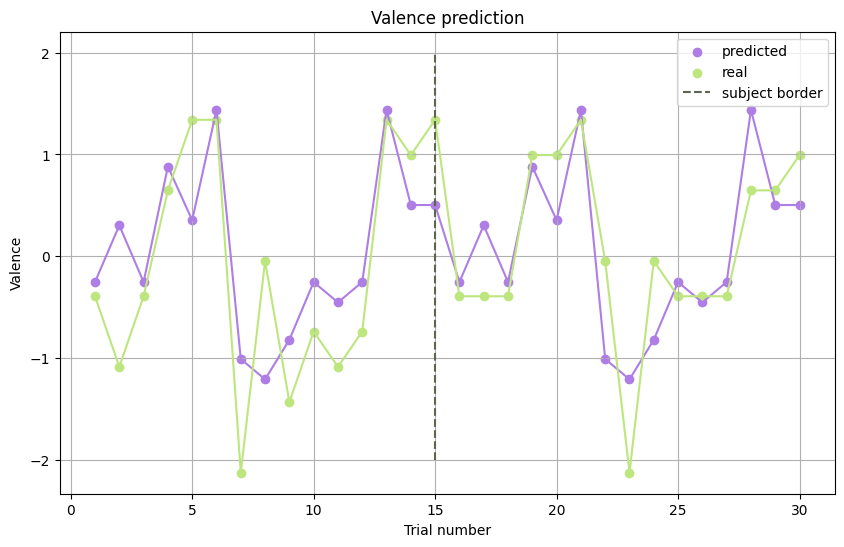

In [29]:
plt.figure(figsize=(10, 6))
times = np.arange(1, 31)
plt.grid()
plt.scatter(times, prediction_valence, label = 'predicted', color='#AE7DE5')
plt.plot(times, prediction_valence, color='#AE7DE5')
plt.scatter(times, test_y_valence, label = 'real', color='#BDE67E')
plt.plot(times, test_y_valence,  color='#BDE67E')

plt.vlines(15, ymax=2, ymin=-2, linestyles='--', label = 'subject border', color='#5C664D')
plt.legend()
plt.title('Valence prediction')
plt.ylabel('Valence')
plt.xlabel('Trial number')

Text(0.5, 0, 'Trial number')

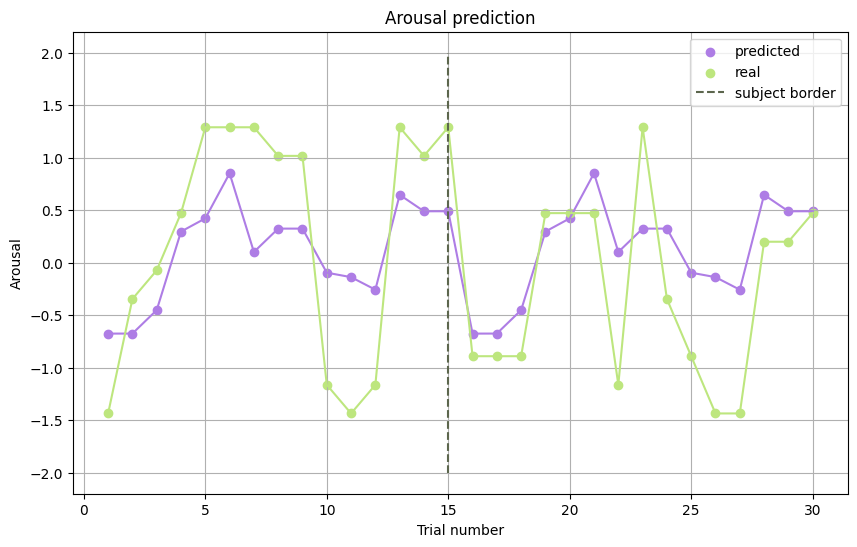

In [30]:
plt.figure(figsize=(10, 6))
times = np.arange(1, 31)
plt.grid()
plt.scatter(times, prediction_arousal, label = 'predicted', color='#AE7DE5')
plt.plot(times, prediction_arousal, color='#AE7DE5')
plt.scatter(times, test_y_arousal, label = 'real', color='#BDE67E')
plt.plot(times, test_y_arousal,  color='#BDE67E')

plt.vlines(15, ymax=2, ymin=-2, linestyles='--', label = 'subject border', color='#5C664D')
plt.legend()
plt.title('Arousal prediction')
plt.ylabel('Arousal')
plt.xlabel('Trial number')

## Дообучение трансформера

In [31]:
from transformers import AutoModel
import torch

In [155]:
!hf auth login

^C


In [80]:
model = AutoModel.from_pretrained("brain-bzh/reve-base", trust_remote_code=True, torch_dtype="auto")
pos_bank = AutoModel.from_pretrained("brain-bzh/reve-positions", trust_remote_code=True, torch_dtype="auto")

Loading weights:   0%|          | 0/140 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1 [00:00<?, ?it/s]

In [33]:
print(model)

Reve(
  (transformer): TransformerBackbone(
    (layers): ModuleList(
      (0-21): 22 x ModuleList(
        (0): Attention(
          (norm): RMSNorm()
          (to_qkv): Linear(in_features=512, out_features=1536, bias=False)
          (to_out): Linear(in_features=512, out_features=512, bias=False)
          (attend): ClassicalAttention()
        )
        (1): FeedForward(
          (net): Sequential(
            (0): RMSNorm()
            (1): Linear(in_features=512, out_features=2722, bias=False)
            (2): GEGLU()
            (3): Linear(in_features=1361, out_features=512, bias=False)
          )
        )
      )
    )
  )
  (to_patch_embedding): Sequential(
    (0): Linear(in_features=200, out_features=512, bias=True)
  )
  (fourier4d): FourierEmb4D()
  (mlp4d): Sequential(
    (0): Linear(in_features=4, out_features=512, bias=False)
    (1): GELU(approximate='none')
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  )
  (ln): LayerNorm((512,), eps=1e-05, el

In [81]:
import torch
import torch.nn as nn
from transformers import AutoModel

device = "cpu"

class ReveRegressor(nn.Module):
    def __init__(self, reve_model, hidden_dim=256, dropout=0.2):
        super().__init__()
        self.reve = reve_model
        self.embedding_dim = reve_model.config.embed_dim
        self.reg_head = nn.Sequential(
            nn.LayerNorm(self.embedding_dim),
            nn.Linear(self.embedding_dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 2)
        )

    def forward(self, eeg, positions):
        outputs = self.reve(eeg, positions)
        x = outputs.mean(dim=(1, 2))
        out = self.reg_head(x)
        return out

In [35]:
channels = epochs[0].ch_names
positions = pos_bank(channels)

In [37]:
def get_x_epochs(epochs, subject_ids):
    selected_epochs = np.array(epochs)[subject_ids]
    x_events = []
    for selected in selected_epochs:
        for event in selected:
            x_events.append(event)
    return x_events

In [38]:
train_x_raw = get_x_epochs(subject_epochs, np.array(train_subj)-1)
val_x_raw = get_x_epochs(subject_epochs, np.array([val_subj])-1)
test_x_raw = get_x_epochs(subject_epochs, np.array(test_subj)-1)

In [41]:
train_y = [list(pair) for pair in list(zip(train_y_valence, train_y_arousal))]
val_y = [list(pair) for pair in list(zip(val_y_valence, val_y_arousal))]
test_y = [list(pair) for pair in list(zip(test_y_valence, test_y_arousal))]

In [42]:
from torch.utils.data import Dataset

class EEGDataset(Dataset):
    def __init__(self, x, y, electrode_pos):
        self.x = torch.tensor(x).float()
        self.y = torch.tensor(y).float()
        self.positions = electrode_pos

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        eeg = self.x[idx]
        y = self.y[idx]
        pos = self.positions
        return eeg, pos, y

In [93]:
from torch.utils.data import DataLoader
train_dataset = EEGDataset(train_x_raw, train_y, positions)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_dataset = EEGDataset(val_x_raw, val_y, positions)

val_loader = DataLoader(
    val_dataset,
    shuffle=True
)

In [95]:
regression_model = ReveRegressor(model).to(device)
optimizer = torch.optim.Adam(regression_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

for param in regression_model.reve.parameters():
    param.requires_grad = True

for epoch in range(15):
    regression_model.train()
    for eeg, pos, y in train_loader:
        eeg, pos, y = eeg.to(device), pos.to(device), y.to(device)

        optimizer.zero_grad()
        preds = regression_model(eeg, pos)

        loss = criterion(preds, y)
        loss.backward()
        optimizer.step()
    regression_model.eval()
    val_loss = 0

    with torch.no_grad():
        for eeg, pos, y in val_loader:
            eeg, pos, y = eeg.to(device), pos.to(device), y.to(device)

            preds = regression_model(eeg, pos)
            val_loss += criterion(preds, y).item()

    print(f"Epoch {epoch}: val_loss = {val_loss:.4f}")

Epoch 0: val_loss = 26.8615
Epoch 1: val_loss = 22.8474
Epoch 2: val_loss = 15.1115
Epoch 3: val_loss = 15.7464
Epoch 4: val_loss = 15.1146
Epoch 5: val_loss = 15.3890
Epoch 6: val_loss = 15.0959
Epoch 7: val_loss = 15.0661
Epoch 8: val_loss = 15.1423
Epoch 9: val_loss = 15.0474
Epoch 10: val_loss = 15.1666
Epoch 11: val_loss = 15.1123
Epoch 12: val_loss = 15.1039
Epoch 13: val_loss = 15.0559
Epoch 14: val_loss = 15.0053


In [96]:
test_dataset = EEGDataset(test_x_raw, test_y, positions)
test_loader = DataLoader(
    test_dataset
)

In [97]:
all_preds = []
all_targets = []
with torch.no_grad():
    for eeg, pos, y in test_loader:
        eeg = eeg.to(device)
        pos = pos.to(device)
        y = y.to(device)

        preds = regression_model(eeg, pos)

        all_preds.append(preds.cpu())
        all_targets.append(y.cpu())
all_preds = torch.cat(all_preds)
all_targets = torch.cat(all_targets)

In [98]:
from sklearn.metrics import mean_squared_error

y_true = all_targets.numpy()
y_pred = all_preds.numpy()

valence_rmse = root_mean_squared_error(y_true[:, 0], y_pred[:, 0])
arousal_rmse = root_mean_squared_error(y_true[:, 1], y_pred[:, 1])

print("Valence RMSE:", valence_rmse)
print("Aurosal RMSE:", arousal_rmse)


Valence RMSE: 1.0002022981643677
Aurosal RMSE: 1.0001522302627563


In [99]:
y_pred

array([[0.02011462, 0.0174496 ],
       [0.02011494, 0.01744958],
       [0.02011493, 0.01744956],
       [0.02011409, 0.01744962],
       [0.02011485, 0.0174496 ],
       [0.0201145 , 0.01744961],
       [0.02011438, 0.01744968],
       [0.02011307, 0.01744977],
       [0.02011463, 0.0174496 ],
       [0.02011479, 0.01744959],
       [0.02011473, 0.01744965],
       [0.02011451, 0.01744958],
       [0.02011484, 0.01744961],
       [0.02011452, 0.01744958],
       [0.02011447, 0.01744959],
       [0.02011447, 0.01744964],
       [0.02011494, 0.01744959],
       [0.0201145 , 0.01744955],
       [0.02011451, 0.0174496 ],
       [0.02011474, 0.0174496 ],
       [0.02011457, 0.01744962],
       [0.02011462, 0.0174496 ],
       [0.02011464, 0.0174496 ],
       [0.02011464, 0.01744964],
       [0.02011487, 0.01744962],
       [0.02011482, 0.01744959],
       [0.02011469, 0.01744959],
       [0.02011459, 0.0174496 ],
       [0.02011477, 0.01744959],
       [0.02011449, 0.01744955]], dtype=flo

Text(0.5, 0, 'Trial number')

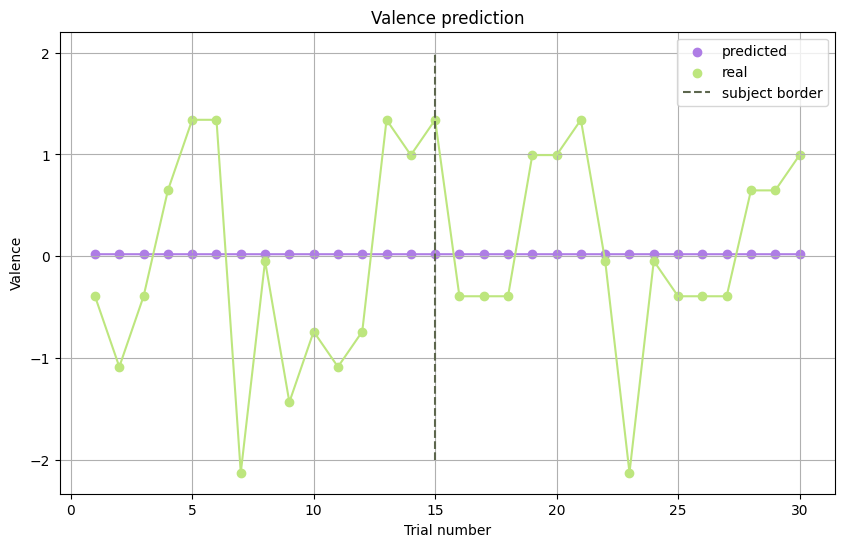

In [100]:
plt.figure(figsize=(10, 6))
times = np.arange(1, 31)
plt.grid()
plt.scatter(times, y_pred[:, 0], label = 'predicted', color='#AE7DE5')
plt.plot(times, y_pred[:, 0], color='#AE7DE5')
plt.scatter(times, test_y_valence, label = 'real', color='#BDE67E')
plt.plot(times, test_y_valence,  color='#BDE67E')

plt.vlines(15, ymax=2, ymin=-2, linestyles='--', label = 'subject border', color='#5C664D')
plt.legend()
plt.title('Valence prediction')
plt.ylabel('Valence')
plt.xlabel('Trial number')

Text(0.5, 0, 'Trial number')

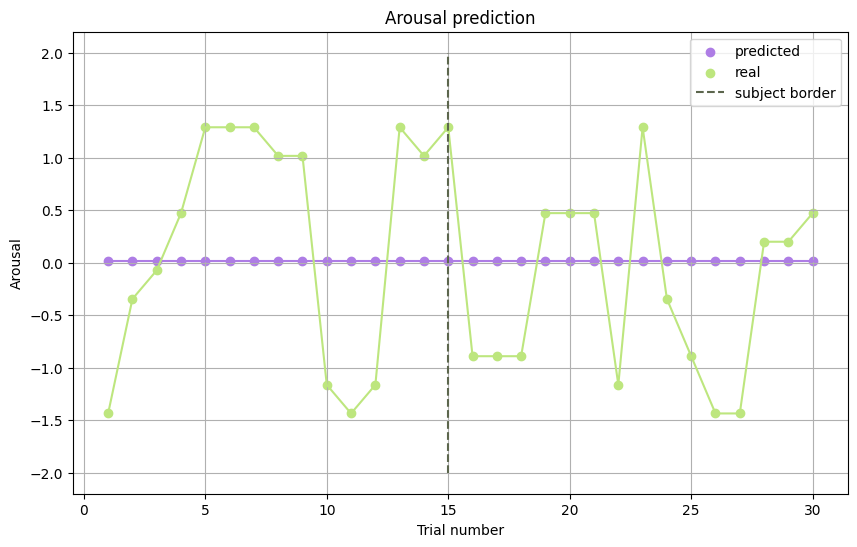

In [101]:
plt.figure(figsize=(10, 6))
times = np.arange(1, 31)
plt.grid()
plt.scatter(times, y_pred[:, 1], label = 'predicted', color='#AE7DE5')
plt.plot(times, y_pred[:, 1], color='#AE7DE5')
plt.scatter(times, test_y_arousal, label = 'real', color='#BDE67E')
plt.plot(times, test_y_arousal,  color='#BDE67E')

plt.vlines(15, ymax=2, ymin=-2, linestyles='--', label = 'subject border', color='#5C664D')
plt.legend()
plt.title('Arousal prediction')
plt.ylabel('Arousal')
plt.xlabel('Trial number')